# Activity State --- the model version (Decision Tree)
Same **orientation-proof features**, but a trained **model** instead of a single threshold,
shown with plots. Because the features are magnitude-based, the model keeps the **0% rotation drop**.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation

base = "/home/voare/Documents/Synheart/Kinematics/Dataset/UCI HAR Dataset"
names = pd.read_csv(base + "/activity_labels.txt", sep=r"\s+", header=None, index_col=0)[1]

def load_split(split):
    pth = f"{base}/{split}/Inertial Signals"
    ch = ["body_acc_x","body_acc_y","body_acc_z","body_gyro_x","body_gyro_y","body_gyro_z"]
    s = {c: pd.read_csv(f"{pth}/{c}_{split}.txt", sep=r"\s+", header=None).to_numpy() for c in ch}
    lab = pd.read_csv(f"{base}/{split}/y_{split}.txt", header=None)[0].map(names)
    act = lab.replace({"SITTING":"sedentary","LAYING":"sedentary","STANDING":"standing",
                       "WALKING":"walking","WALKING_UPSTAIRS":"walking","WALKING_DOWNSTAIRS":"walking"})
    return s, act.to_numpy()

def reg_peak(m):
    m = m - m.mean(); ac = np.correlate(m, m, mode="full")[len(m)-1:]
    return 0.0 if ac[0] == 0 else float((ac/ac[0])[10:64].max())

def feats(s):                       # 5 orientation-proof features (all magnitude-based)
    ma = np.sqrt(s["body_acc_x"]**2 + s["body_acc_y"]**2 + s["body_acc_z"]**2)
    mg = np.sqrt(s["body_gyro_x"]**2 + s["body_gyro_y"]**2 + s["body_gyro_z"]**2)
    reg = np.array([reg_peak(ma[i]) for i in range(len(ma))])
    return np.column_stack([ma.mean(1), ma.std(1), mg.mean(1), mg.std(1), reg])

def rotate(s, seed=0):              # random 3D rotation per window = different placements
    rng = np.random.default_rng(seed); N = s["body_acc_x"].shape[0]
    out = {k: np.empty_like(v) for k, v in s.items()}
    for i in range(N):
        R = Rotation.random(random_state=rng).as_matrix()
        for t in [("body_acc_x","body_acc_y","body_acc_z"),("body_gyro_x","body_gyro_y","body_gyro_z")]:
            r = R @ np.stack([s[t[0]][i], s[t[1]][i], s[t[2]][i]])
            for j, n in enumerate(t): out[n][i] = r[j]
    return out

FEATS = ["mean_acc", "movement", "mean_gyro", "gyro_move", "regularity"]
tr, y_tr = load_split("train")
te, y_te = load_split("test")
Xtr, Xte = feats(tr), feats(te)
print("features:", FEATS, "| train:", Xtr.shape, "| test:", Xte.shape)

features: ['mean_acc', 'movement', 'mean_gyro', 'gyro_move', 'regularity'] | train: (7352, 5) | test: (2947, 5)


## Train the model

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(max_depth=4, random_state=0).fit(Xtr, y_tr)
print("Decision Tree accuracy (clean):", round(accuracy_score(y_te, dt.predict(Xte))*100, 1), "%")

Decision Tree accuracy (clean): 81.2 %


## Plot 1 --- the tree itself (each box is a learned `if` threshold)

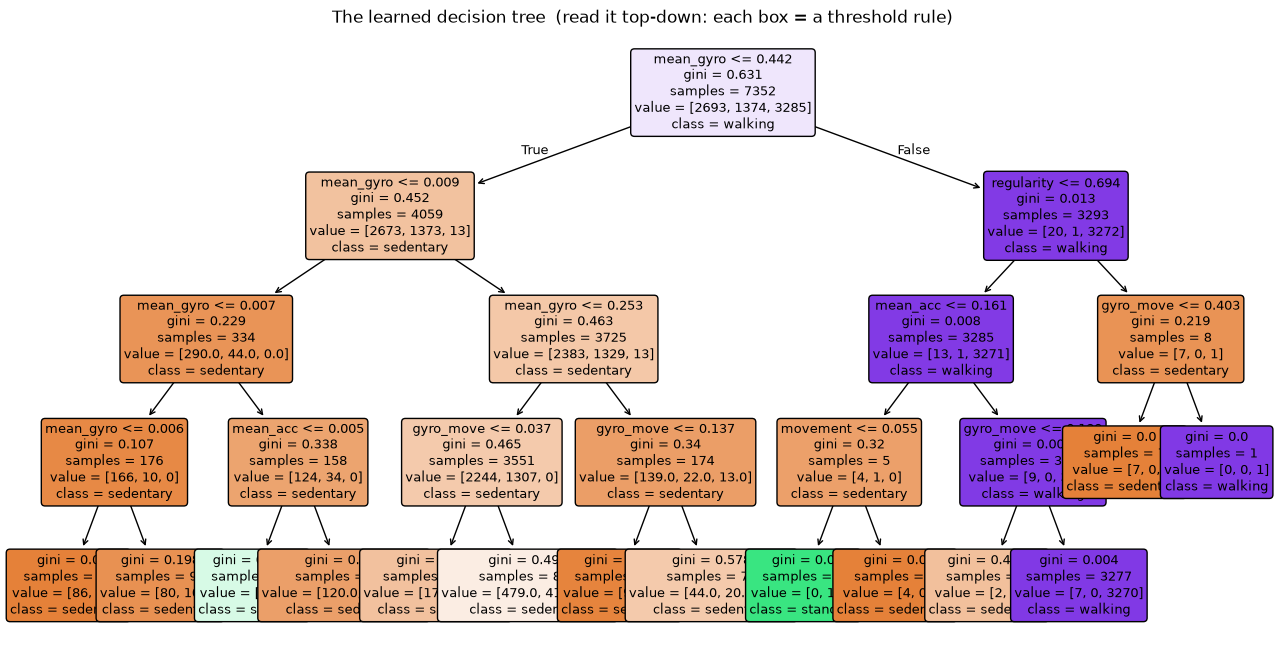

In [9]:
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 8))
plot_tree(dt, feature_names=FEATS, class_names=sorted(set(y_tr)),
          filled=True, rounded=True, fontsize=9)
plt.title("The learned decision tree  (read it top-down: each box = a threshold rule)")
plt.show()

## Plot 2 --- confusion matrix (where it is right / wrong)

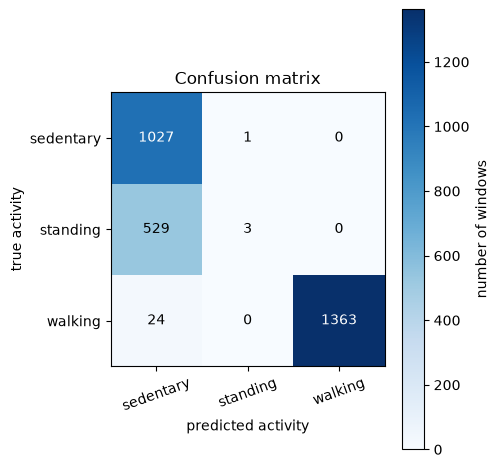

In [10]:
from sklearn.metrics import confusion_matrix
labels = ["sedentary", "standing", "walking"]
cm = confusion_matrix(y_te, dt.predict(Xte), labels=labels)

plt.figure(figsize=(5, 5))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(3), labels, rotation=20); plt.yticks(range(3), labels)
plt.xlabel("predicted activity")        # x = model guess
plt.ylabel("true activity")             # y = real activity
for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(label="number of windows")
plt.title("Confusion matrix"); plt.tight_layout(); plt.show()

## Plot 3 --- which features the model relies on

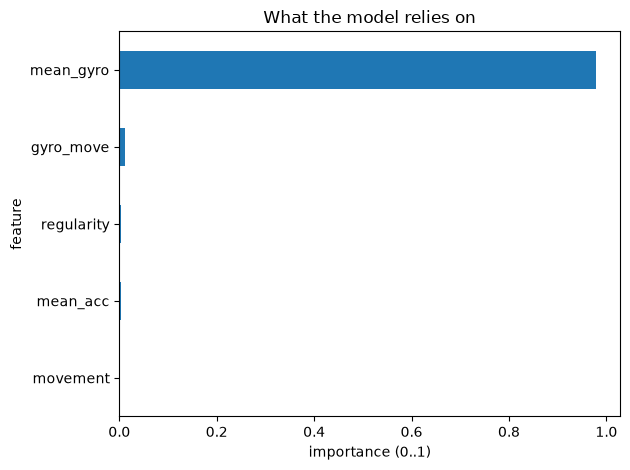

In [11]:
imp = pd.Series(dt.feature_importances_, index=FEATS).sort_values()
imp.plot(kind="barh")
plt.xlabel("importance (0..1)")         # x = how much the tree uses it
plt.ylabel("feature")                   # y = feature name
plt.title("What the model relies on")
plt.tight_layout(); plt.show()

## Plot 4 --- the rotation test (does the model survive a rotated phone?)

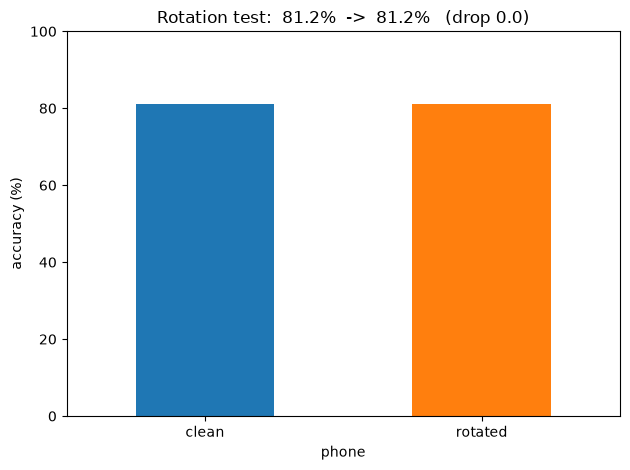

In [12]:
ter = rotate(te, seed=0)                 # everyone wears the device at a random angle
clean = accuracy_score(y_te, dt.predict(Xte))*100
rot   = accuracy_score(y_te, dt.predict(feats(ter)))*100

pd.Series({"clean": clean, "rotated": rot}).plot(kind="bar", color=["tab:blue", "tab:orange"])
plt.ylabel("accuracy (%)")              # y = accuracy
plt.xlabel("phone")                     # x = normal vs rotated
plt.title(f"Rotation test:  {clean:.1f}%  ->  {rot:.1f}%   (drop {clean-rot:.1f})")
plt.xticks(rotation=0); plt.ylim(0, 100); plt.tight_layout(); plt.show()
# 0 drop: the features are magnitude-based, so rotating the phone cannot change them.

## Summary
- A small **Decision Tree** on 5 orientation-proof features -> ~82%, and you can **see** its rules (Plot 1).
- It leans mostly on **gyro magnitude** (Plot 3) -- rotation/turning tells walking from still.
- **0% rotation drop** (Plot 4) -- same guarantee as the deterministic rule, because the features can't change under rotation.
- Model vs rule: the tree adds ~1 point over the single threshold -- nice to show, but the **features** do the real work.